In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import numpy as np

14336 eventi di Channel 1 su 272400
14336 eventi di Channel 2 su 272400
14337 eventi di Channel 3 su 272400
14337 eventi di Channel 4 su 272400
14337 eventi di Channel 5 su 272400
14337 eventi di Channel 6 su 272400
14337 eventi di Channel 7 su 272400
14337 eventi di Channel 8 su 272400
14337 eventi di Channel 9 su 272400
14337 eventi di Channel 10 su 272400
14337 eventi di Channel 11 su 272400
14337 eventi di Channel 12 su 272400
14337 eventi di Channel 13 su 272400
14337 eventi di Channel 14 su 272400
14337 eventi di Channel 15 su 272400
14337 eventi di Channel 16 su 272400
14337 eventi di Channel 17 su 272400
14337 eventi di Channel 18 su 272400
14336 eventi di Channel 19 su 272400


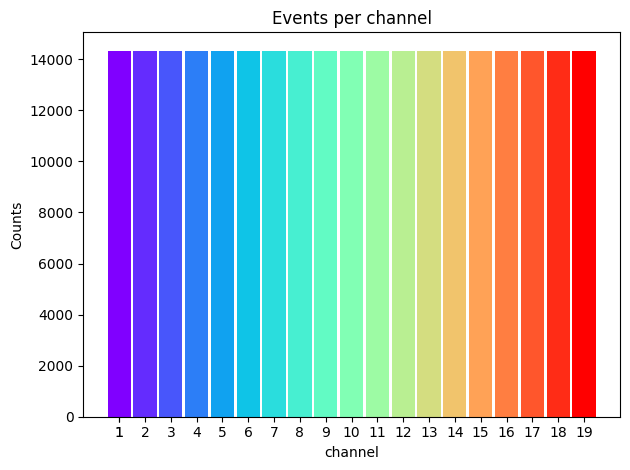

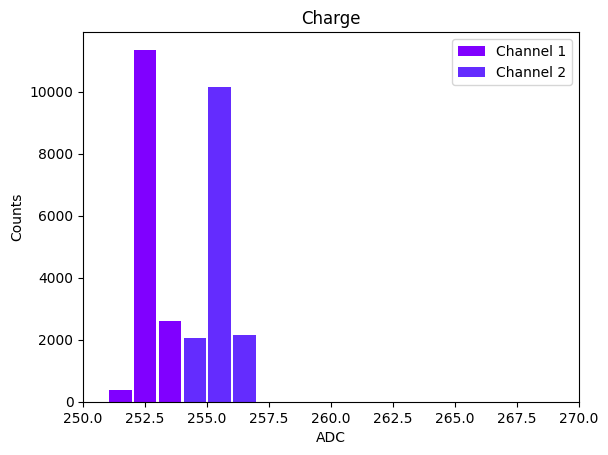

In [25]:
testc = cm.rainbow(np.linspace(0, 1, 19))

df = pd.read_csv('test.csv')
columns = df.columns.values.tolist()

sdf = {}
for i in range(1, 20):
    sdf[f'Channel_{i}'] = df[(df['Channel'] == i)].reset_index(drop=True)
    print(f'{len(sdf[f'Channel_{i}'])} eventi di Channel {i} su {len(df)}')

start_range = 1
plotted_channels = 19

for col in columns:
    if col == "Channel":
        plt.figure()
        for i in range(start_range, 1+plotted_channels):
            plt.title('Events per channel')
            plt.hist(sdf[f'Channel_{i}'][col], color=testc[i-1], rwidth=0.9, bins=np.linspace(0.5, 19.5, 20), label=f'Channel {i}')
            # lgd = plt.legend(bbox_to_anchor=(1.3, 1.1), fontsize=10)
            plt.xticks(np.linspace(1, 19, 20, dtype=int))
            plt.xlabel('channel')
            plt.tight_layout()
            plt.ylabel('Counts')
            plt.savefig('allhist.png')
    elif col == "Energy":
        plt.figure()
        for i in range(start_range, 3):
            plt.title('Charge')
            plt.hist(sdf[f'Channel_{i}'][col], color=testc[i-1], rwidth=0.9, label=f'Channel {i}', bins=np.linspace(250, 270, 21))
            lgd2 = plt.legend(fontsize=10)
            plt.xlim([250, 270])
            plt.xlabel('ADC')
            plt.ylabel('Counts')
            plt.savefig('energy.png')
plt.show()

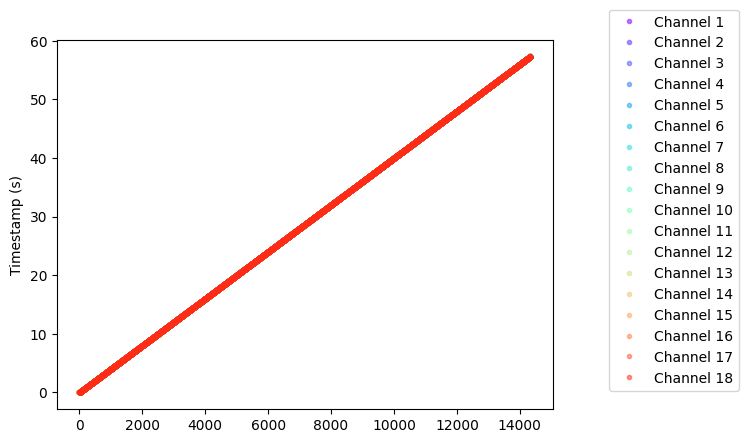

In [3]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
for i in range(1, 19):
    ax1.plot((sdf[f'Channel_{i}']['Timestamp[ns]'][1:]-sdf['Channel_1']['Timestamp[ns]'][1])/1e9, color=testc[i-1], label=f'Channel {i}', alpha=0.5, marker='.', linestyle='')
ax1.set_ylabel('Timestamp (s)')
plt.legend(bbox_to_anchor=(1.1, 1.1), fontsize=10)
plt.show()

In [4]:
wrong_CRC = 0
for idx, row in df.iterrows():
    if not row['CRC']:
        wrong_CRC += 1
if wrong_CRC == 0:
    print('Tutti pacchetti correttamente arrivati!')
else:
    print(f"Sono sbagliati {wrong_CRC} CRC su {len(df)} eventi!")
    print(df[(df['CRC'] == False)])
    pass

Tutti pacchetti correttamente arrivati!
